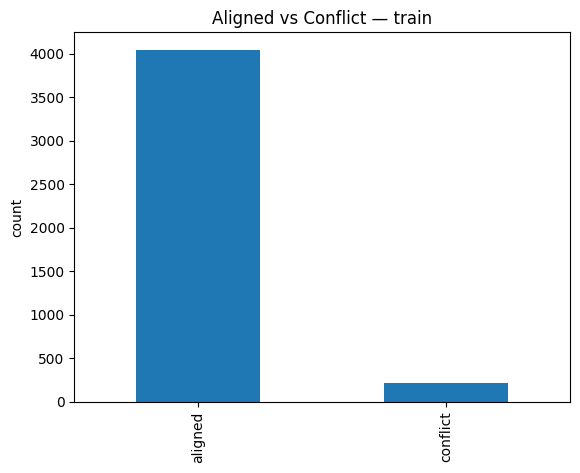

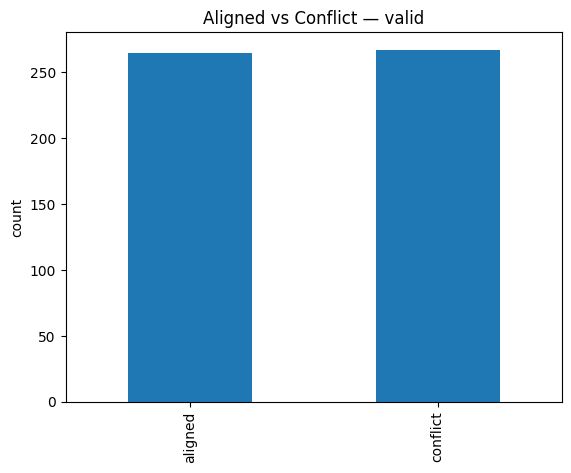

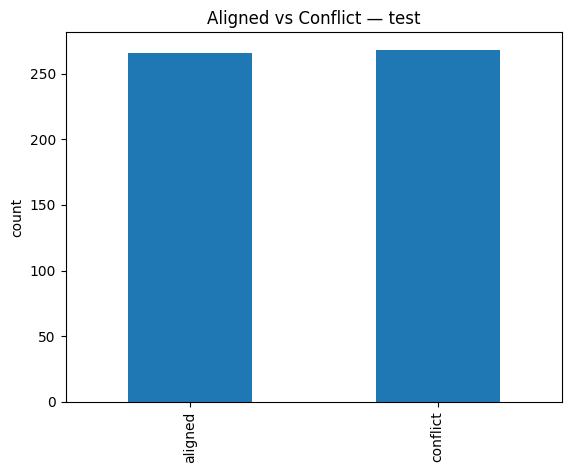

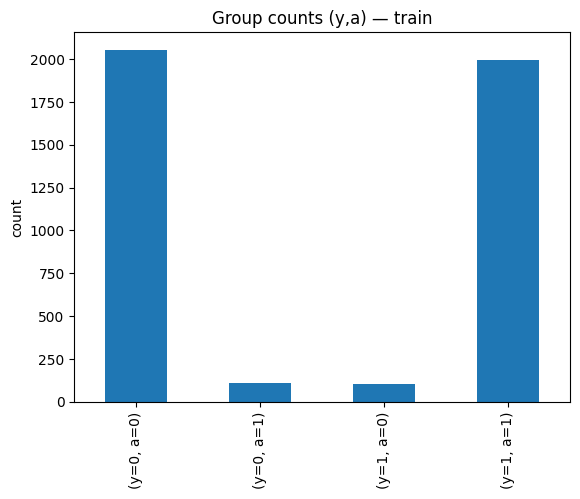

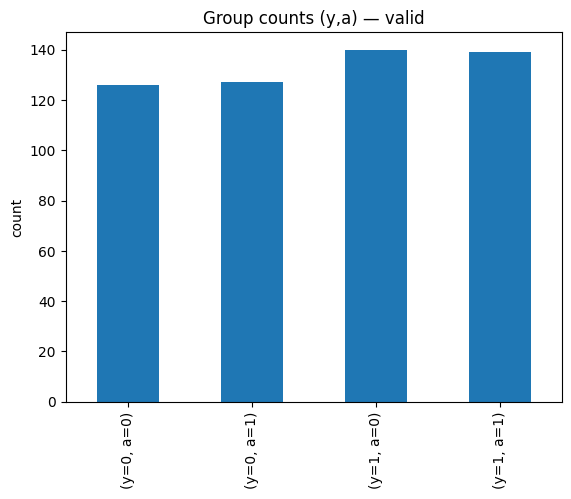

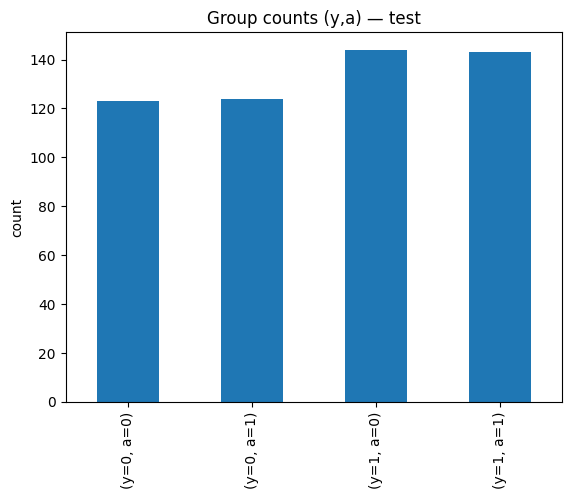

In [ ]:
# === Waterbirds bias/alignment stats ===
import os
import pandas as pd
import matplotlib.pyplot as plt

ROOT = "/home/ulkar/debias-medimg/data/waterbirds"
FILES = {"train": "train.csv", "valid": "valid.csv", "test": "test.csv"}

def load_split(split):
    df = pd.read_csv(os.path.join(ROOT, FILES[split]))
    # y = class label (0 landbird, 1 waterbird)
    # place = background (0 land, 1 water)
    df = df.copy()
    df["aligned"] = (df["y"] == df["place"])
    return df

# -------- Summary per split --------
rows = []
dfs = {}
for split in ["train", "valid", "test"]:
    df = load_split(split)
    dfs[split] = df
    total = len(df)
    n_align = int(df["aligned"].sum())
    n_conf = total - n_align
    y_counts = df["y"].value_counts().reindex([0,1], fill_value=0)
    a_counts = df["place"].value_counts().reindex([0,1], fill_value=0)
    rows.append({
        "split": split,
        "total": total,
        "aligned": n_align,
        "conflict": n_conf,
        "aligned_%": round(100*n_align/total, 2) if total else 0.0,
        "conflict_%": round(100*n_conf/total, 2) if total else 0.0,
        "y=0": int(y_counts[0]), "y=1": int(y_counts[1]),
        "a=0": int(a_counts[0]), "a=1": int(a_counts[1]),
    })

summary_df = pd.DataFrame(rows).set_index("split").sort_index()
summary_df

# -------- Group counts per split: (y, a) --------
group_counts = {}
for split, df in dfs.items():
    gc = df.groupby(["y","place"]).size().unstack("place", fill_value=0)
    # nice column names
    gc.columns = [f"a={c}" for c in gc.columns]
    gc.index = [f"y={i}" for i in gc.index]
    group_counts[split] = gc

# Show group counts for each split (uncomment to display)
# group_counts["train"], group_counts["valid"], group_counts["test"]

# -------- Per-class counts (with aligned/conflict) --------
per_class = {}
for split, df in dfs.items():
    pc = (df
          .assign(conflict=~df["aligned"])
          .groupby(["class_id","class_name"])
          .agg(total=("y","size"),
               aligned=("aligned","sum"),
               conflict=("conflict","sum"))
          .reset_index())
    pc["conflict_rate_%"] = (pc["conflict"] / pc["total"] * 100).round(2)
    per_class[split] = pc.sort_values(["conflict_rate_%","total"], ascending=[False, False])

# Show per-class tables (uncomment any)
# per_class["train"].head(20)
# per_class["valid"].head(20)
# per_class["test"].head(20)

import matplotlib.pyplot as plt

# Aligned vs Conflict per split
for split in ["train","valid","test"]:
    s = summary_df.loc[split, ["aligned","conflict"]]
    plt.figure()
    s.plot(kind="bar")
    plt.title(f"Aligned vs Conflict — {split}")
    plt.ylabel("count")
    plt.show()

# Group counts (y,a) per split
for split, gc in group_counts.items():
    plt.figure()
    gc.stack().plot(kind="bar")
    plt.title(f"Group counts (y,a) — {split}")
    plt.ylabel("count")
    plt.show()


## Paper-ready group counts table

The cell below computes group counts (y = class, a = background) for train/valid/test, displays a concise table, and writes a CSV and a LaTeX table to the `evaluation/` folder for inclusion in the paper.

In [8]:
import os
import pandas as pd

ROOT = "/home/ulkar/debias-medimg/data/waterbirds"
FILES = {"train": "train.csv", "valid": "valid.csv", "test": "test.csv"}

def load_split(split):
    df = pd.read_csv(os.path.join(ROOT, FILES[split]))
    return df.copy()

rows = []
for split in ["train", "valid", "test"]:
    df = load_split(split)
    gc = df.groupby(["y", "place"]).size().unstack("place", fill_value=0)

    # Ensure all y/place combinations exist
    gc = gc.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

    rows.append(
        {
            "split": split,
            "y0_a0": int(gc.loc[0, 0]),
            "y0_a1": int(gc.loc[0, 1]),
            "y1_a0": int(gc.loc[1, 0]),
            "y1_a1": int(gc.loc[1, 1]),
            "total": int(gc.values.sum()),
        }
    )

out_df = pd.DataFrame(rows).set_index("split").reindex(["train", "valid", "test"])
out_df

# Write CSV and LaTeX into evaluation/ for paper inclusion
out_dir = "/home/ulkar/debias-medimg/data/waterbirds"
os.makedirs(out_dir, exist_ok=True)
csv_path = os.path.join(out_dir, "group_counts_table.csv")
out_df.to_csv(csv_path)

print("Wrote CSV to", csv_path)

Wrote CSV to /home/ulkar/debias-medimg/data/waterbirds/group_counts_table.csv
